In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
iris = load_iris()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Feature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

print("\nDataset shape:")
print(iris.data.shape)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Dataset shape:
(150, 4)


In [4]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


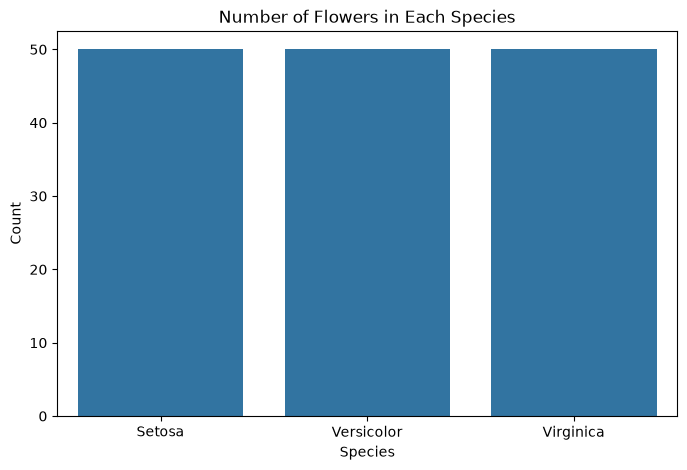

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="species_name"
)

plt.title("Number of Flowers in Each Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

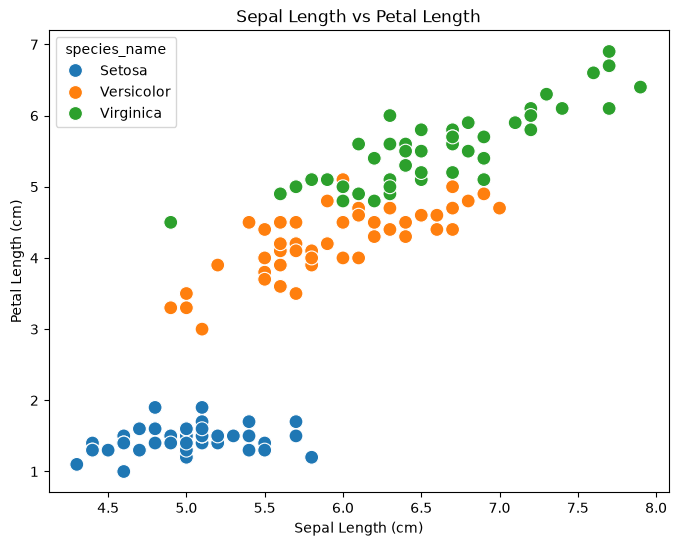

In [10]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="species_name",
    s=100
)

plt.title("Sepal Length vs Petal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")

plt.show()

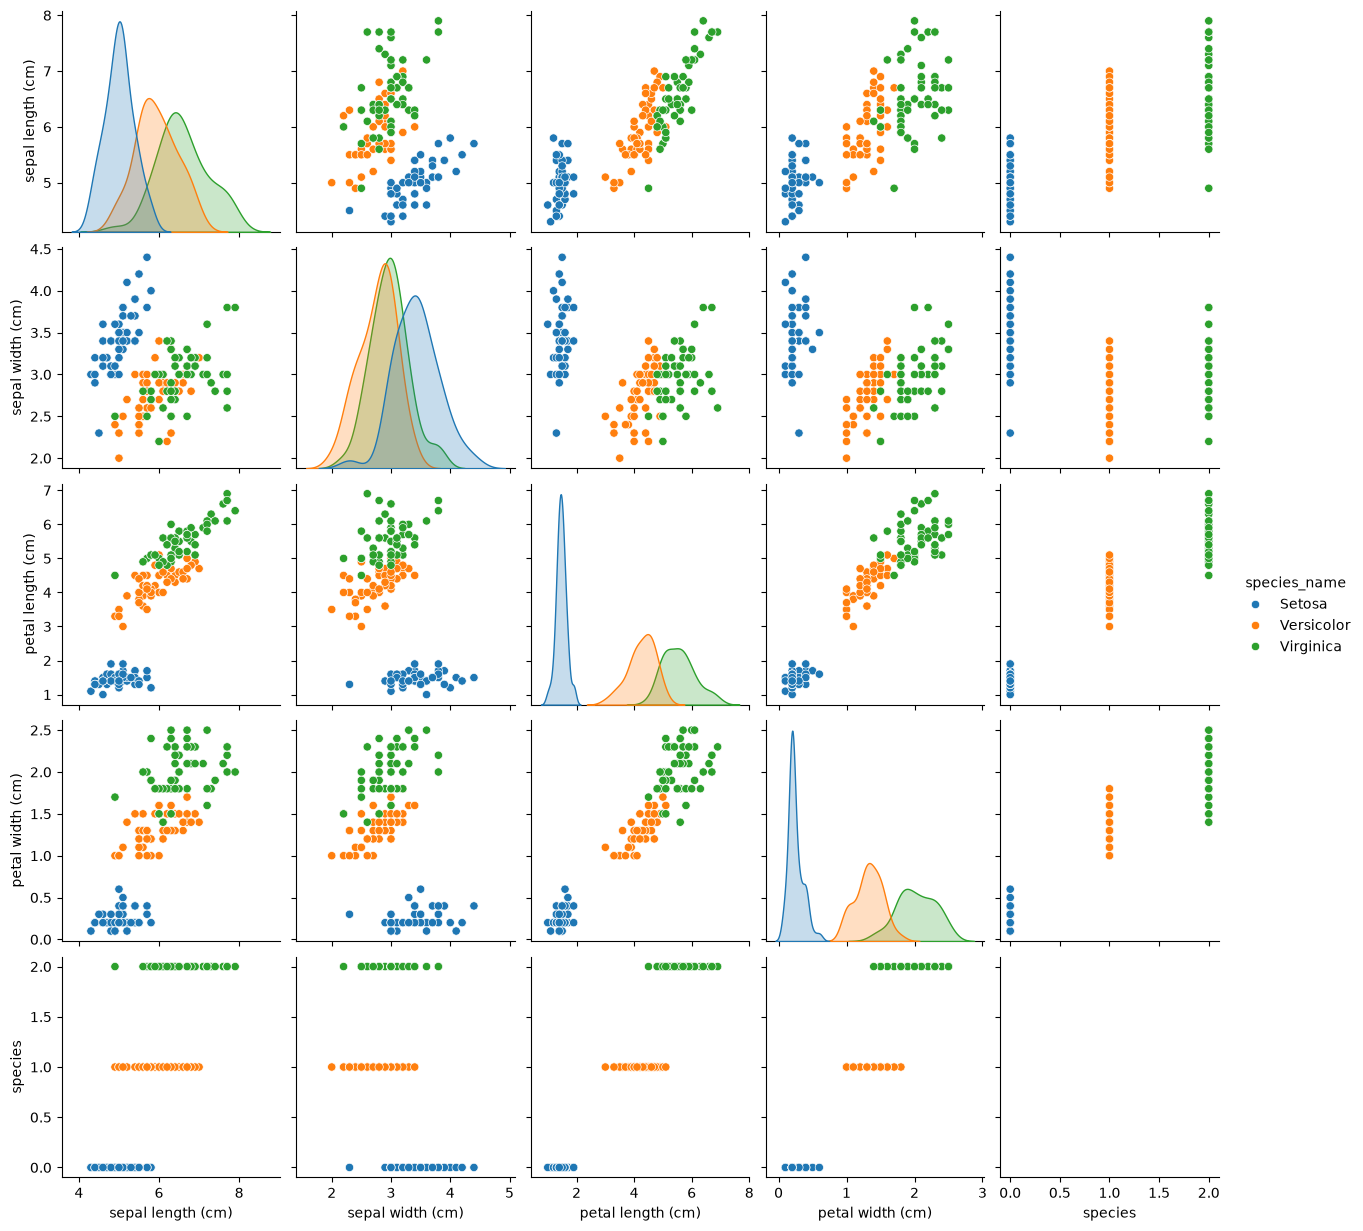

In [11]:
sns.pairplot(
    df,
    hue="species_name"
)

plt.show()

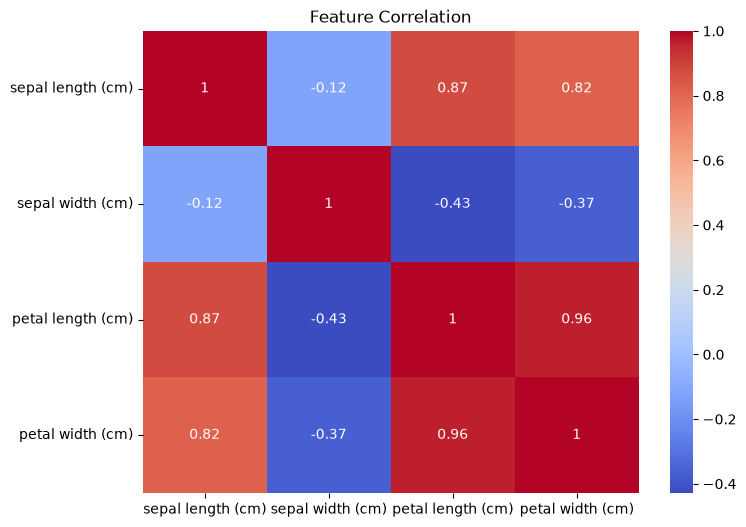

In [12]:
plt.figure(figsize=(8, 6))

correlation = df[iris.feature_names].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

In [13]:
X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [16]:
model = LogisticRegression(
    max_iter=200
)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [17]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9333333333333333
Accuracy Percentage: 93.33333333333333 %


In [19]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [20]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


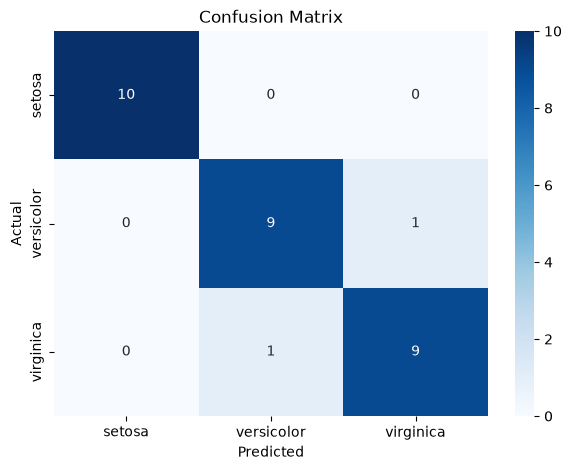

In [21]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)

print("Predicted Species:", iris.target_names[prediction[0]])

Predicted Species: setosa


In [23]:
new_flower = np.array([
    [6.5, 3.0, 5.2, 2.0]
])

new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)

print("Predicted Species:", iris.target_names[prediction[0]])

Predicted Species: virginica


In [24]:
joblib.dump(model, "iris_model.pkl")
joblib.dump(scaler, "iris_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [25]:
loaded_model = joblib.load("iris_model.pkl")
loaded_scaler = joblib.load("iris_scaler.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [26]:
new_flower = np.array([
    [5.9, 3.0, 5.1, 1.8]
])

new_flower_scaled = loaded_scaler.transform(new_flower)

prediction = loaded_model.predict(new_flower_scaled)

print("Predicted Species:", iris.target_names[prediction[0]])

Predicted Species: virginica
